# データサイエンス特論 第6回 事前課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

#### 事前課題1
事前資料 p.17 の例題（$n=10$，$\bar{X}=101$，$S^2=1.8$，$\mu=100$）を有意水準1％で検定する。

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

In [39]:
def t_plot_fill_rejection(mu, sigma, df, xrange, p):
    start = mu - xrange * sigma
    end = mu + xrange * sigma

    X = np.arange(start, end, 0.01)
    Y = t.pdf(X, df=df, loc=mu, scale=sigma)

    fig, ax = plt.subplots()
    ax.plot(X, Y, color='blue')

    alpha = 1 - p
    x_lower = t.ppf(alpha / 2, df=df, loc=mu, scale=sigma)
    x_upper = t.ppf(1 - alpha / 2, df=df, loc=mu, scale=sigma)

    X_lower = np.arange(start, x_lower, 0.001)
    ax.fill_between(X_lower, t.pdf(X_lower, df=df, loc=mu, scale=sigma), color='red', alpha=0.5)
    X_upper = np.arange(x_upper, end, 0.001)
    ax.fill_between(X_upper, t.pdf(X_upper, df=df, loc=mu, scale=sigma), color='red', alpha=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Probability density')
    ax.set_title(f'rejection region (significance level {int(alpha*100)}%): x < {x_lower:.3f}, x > {x_upper:.3f}')
    plt.show()

In [40]:
n = 10
x_bar = 101
s2 = 1.8
mu = 100

T = (x_bar - mu) / np.sqrt(s2 / n)
df = n - 1
alpha = 0.01

t_lower = t.ppf(alpha / 2, df=df)
t_upper = t.ppf(1 - alpha / 2, df=df)

print(f'T = {T}')
print(f'下側0.5%点 = {t_lower}, 上側0.5%点 = {t_upper}')

T = 2.3570226039551585
下側0.5%点 = -3.2498355415921263, 上側0.5%点 = 3.2498355415921254


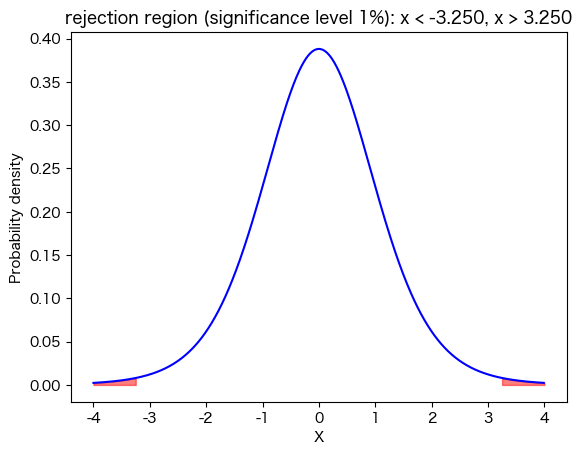

In [41]:
t_plot_fill_rejection(mu=0, sigma=1, df=df, xrange=4, p=1 - alpha)

有意水準5％では棄却された帰無仮説が1％では棄却域より内側にT値が入るため棄却できないという結果になる。つまり有意水準1％では製品の平均重量は変化したとは言えないという結論になる。